ASMA PROJECT:

Step 1: Set up Google Colab

Step 2: Download & load IMDb dataset (text reviews)

Step 3: Preprocess text (cleaning, tokenizing, etc.)

Step 4: Label mapping (sentiment → emotion)

Step 5: Vectorize using TF-IDF

Step 6: Train a machine learning model (Logistic Regression)

Step 7: Evaluate model

Step 8: Test on new reviews

STEP 9: Test with Custom Review

STEP 10: Live Review


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


--2025-10-28 11:12:40--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  12.5MB/s    in 16s     

2025-10-28 11:12:57 (4.90 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]

Dataset Shape: (50000, 2)
                                              review sentiment
0  A great Bugs Bunny cartoon from the earlier ye...  positive
1  Kazan's early film noir won an Oscar. Some of ...  positive
2  Mr. Blandings Builds His Dream House may be th...  positive
3  This is one of the funniest series ever! I lau...  positive
4  As I drove from Skagway, Alaska to Dawson City...  positive
                                              review sentiment emotion
0  A great 

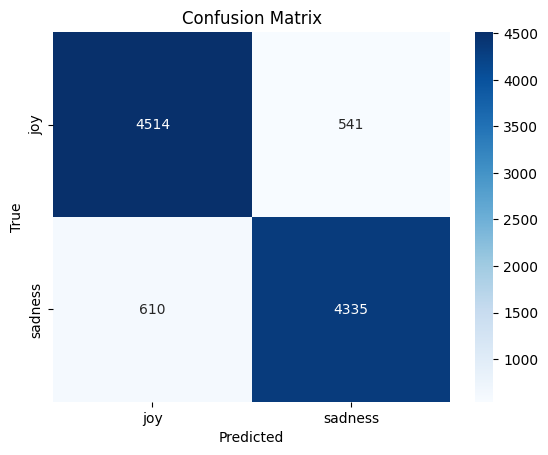

Custom Review Prediction → joy
Custom Review Prediction → sadness


In [ ]:
# ===============================
# STEP 1: Install & Import Packages
# ===============================
!pip install scikit-learn nltk seaborn

import os
import re
import nltk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# ===============================
# STEP 2: Download IMDb Raw Dataset
# ===============================
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xzf aclImdb_v1.tar.gz

# ===============================
# STEP 3: Load Dataset into Pandas
# ===============================
def load_imdb_data(data_dir):
    data = {"review": [], "sentiment": []}
    for label in ["pos", "neg"]:
        folder = os.path.join(data_dir, label)
        for filename in os.listdir(folder):
            with open(os.path.join(folder, filename), "r", encoding="utf-8") as f:
                data["review"].append(f.read())
                data["sentiment"].append("positive" if label == "pos" else "negative")
    return pd.DataFrame(data)

# Load train and test sets
train_df = load_imdb_data("aclImdb/train")
test_df = load_imdb_data("aclImdb/test")

# Combine into single dataframe
df = pd.concat([train_df, test_df]).reset_index(drop=True)
print("Dataset Shape:", df.shape)
print(df.head())

# ===============================
# STEP 4: Map Sentiment → Emotion
# ===============================
df["emotion"] = df["sentiment"].map({"positive": "joy", "negative": "sadness"})
print(df[["review", "sentiment", "emotion"]].head())

# ===============================
# STEP 5: Preprocess Text
# ===============================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    words = text.split()  # tokenize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]  # remove stopwords + lemmatize
    return " ".join(words)

# Apply preprocessing
df["clean_review"] = df["review"].apply(preprocess_text)
print(df[["review", "clean_review", "emotion"]].head())

# ===============================
# STEP 6: Convert Text → TF-IDF Features
# ===============================
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["clean_review"])
y = df["emotion"]

print("TF-IDF Shape:", X.shape)

# ===============================
# STEP 7: Train/Test Split + Model Training
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Training complete")

# ===============================
# STEP 8: Model Evaluation
# ===============================
y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["joy", "sadness"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["joy", "sadness"], yticklabels=["joy", "sadness"], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# STEP 9: Test with Custom Review
# ===============================
sample_review = "The movie was absolutely wonderful, full of great acting and emotion!"
sample_clean = preprocess_text(sample_review)
sample_vec = tfidf.transform([sample_clean])
print("Custom Review Prediction →", model.predict(sample_vec)[0])

sample_review2 = "The film was terrible, boring and a waste of time."
sample_clean2 = preprocess_text(sample_review2)
sample_vec2 = tfidf.transform([sample_clean2])
print("Custom Review Prediction →", model.predict(sample_vec2)[0])





In [ ]:
# ===============================
# STEP 10: Live Review
# ===============================
while True:
    sample_review = input("Enter a movie review (or type 'quit' to exit): ")

    if sample_review.lower() == "quit":
        print("Exiting live demo...")
        break

    # Preprocess + Vectorize
    sample_clean = preprocess_text(sample_review)
    sample_vec = tfidf.transform([sample_clean])

    # Prediction
    prediction = model.predict(sample_vec)[0]
    print("Custom Review Prediction →", prediction)
    print("-" * 50)


Custom Review Prediction → joy
--------------------------------------------------
Custom Review Prediction → sadness
--------------------------------------------------
